# 📘 Tutorial 4: Optimisation Beyond Convexity

> This notebook is provided in a clean, non-executed state for readability and reproducibility.

In **Tutorial 3**, we studied how modifying the update rule — in particular by introducing **momentum** — can change the dynamics of optimisation.

In this tutorial, we shift attention to a deeper difficulty: the fact that the **objective itself may no longer be well behaved**.

Once the landscape becomes non-convex, optimisation is no longer just a matter of descending efficiently toward a single minimum.
Instead, the optimiser may encounter:
- multiple attractive minima,
- sensitivity to initialisation,
- basin boundaries,
- and noisy updates that can either help or hurt progress.

These effects make optimisation fundamentally less predictable.

To make this concrete, we study simple low-dimensional objectives that are easy to visualise directly, while already capturing the key challenges of **non-convex optimisation**.

---

**This tutorial is designed to shift perspective**
- from *“optimisation difficulty is mainly about choosing a better algorithm”*
- to *“even a good local optimiser can fail when the landscape is multi-modal or the gradient is noisy.”*

---

**The emphasis is on developing intuition for**
- how multiple minima create basin-dependent optimisation outcomes,
- why nearby initialisations can lead to very different trajectories,
- how random restarts reveal the structure of a non-convex landscape,
- how noisy gradients change both convergence and basin selection,
- and why noise can sometimes help exploration while harming local convergence.

---

**Key ideas explored include**
- 2D multiwell objectives as simple non-convex testbeds,
- initialisation sensitivity and basin dependence,
- random restarts and distinct final-loss levels,
- noisy gradient descent on convex and non-convex objectives,
- and the trade-off between exploration, stability, and final solution quality.

---

This tutorial builds directly on the earlier study of optimisation dynamics and geometry, but now shows where those tools begin to break down.

In particular, it highlights that:
- local descent does not guarantee globally good behaviour,
- randomness can change not just the path, but also the final minimum reached,
- and optimisation under a fixed compute budget can involve genuine trade-offs rather than a single “best” setting.

These ideas form the conceptual bridge to the next part of the repository: **modelling unknown functions under uncertainty**.

---

**Recommended prerequisites**
- Completion of **Tutorials 1–3** in Part 2
- Basic understanding of gradient descent and momentum
- Familiarity with contour plots and non-convex objectives

---

**Author**: Angze Li

**Last updated**: 2026-04-14

**Version**: v2.0

## 🔧 Setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

def set_seed(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)

def style_ax(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.tick_params(axis="both", labelsize=14)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight("bold")

def gd_step(x, grad, lr):
    return x - lr * grad

@torch.no_grad()
def run_gd(x0, loss_grad_fn, lr, steps=60):
    x = x0.clone()
    xs, losses, grad_norms = [x.clone()], [], []

    for _ in range(steps):
        L, g = loss_grad_fn(x)
        losses.append(float(L))
        grad_norms.append(float(g.norm()))
        x = gd_step(x, g, lr)
        xs.append(x.clone())

    return torch.stack(xs), np.array(losses), np.array(grad_norms)

@torch.no_grad()
def run_noisy_gd(x0, loss_grad_fn, lr, noise_std=0.0, steps=60):
    x = x0.clone()
    xs, losses, grad_norms = [x.clone()], [], []

    for _ in range(steps):
        L, g = loss_grad_fn(x)
        losses.append(float(L))
        grad_norms.append(float(g.norm()))
        g_noisy = g + noise_std * torch.randn_like(g)
        x = gd_step(x, g_noisy, lr)
        xs.append(x.clone())

    return torch.stack(xs), np.array(losses), np.array(grad_norms)

## 1. A 2D non-convex landscape

We now move from simple 1-dimensional examples to a **two-dimensional non-convex objective**.
This is the setting in which optimisation becomes much more representative of real problems: the landscape can contain multiple wells, curved level sets, and several competing descent directions.

The objective is defined as

$$
L(x_1, x_2) = 0.2(x_1^4 + x_2^4) - (x_1^2 + x_2^2) + 0.3 x_1 x_2.
$$

Its gradient is

$$
\nabla L(x_1, x_2)
=
\begin{pmatrix}
0.8x_1^3 - 2x_1 + 0.3x_2 \\
0.8x_2^3 - 2x_2 + 0.3x_1
\end{pmatrix}.
$$

This function is still simple enough to visualise directly, but already rich enough to exhibit the kinds of behaviour that make local optimisation difficult.

---

### What the code does

- `multiwell2d()` defines a callable that returns both:
  - the scalar loss $L(x_1, x_2)$
  - the gradient $\nabla L(x_1, x_2)$

- `contour_plot_2d(...)` evaluates the loss over a grid in the $(x_1, x_2)$ plane.

- The resulting values are plotted as **contour lines**, giving a visual representation of the optimisation landscape.

---

### How to interpret the figure

This contour plot shows a **non-convex surface with multiple low-loss regions**.

Several important features are already visible:

- the level sets are **not circular or elliptical** in the simple quadratic sense,
- the landscape contains **multiple attractive regions**,
- and the local slope can point in very different directions depending on where the optimiser starts.

In other words, this is no longer a problem with one clean valley leading to one obvious minimum.

---

### Why this matters

For convex quadratic objectives, local gradient information is usually enough to understand the optimisation dynamics.

Here, that is no longer true.

Even before running gradient descent, the contour plot suggests that:
- there may be **multiple local minima**,
- different initialisations may converge to different destinations,
- and local optimisation may only explore a small part of the overall landscape.

This 2D multiwell objective will serve as the main testbed for the rest of the tutorial, where we study how **geometry and noise together can make local optimisation unreliable**.

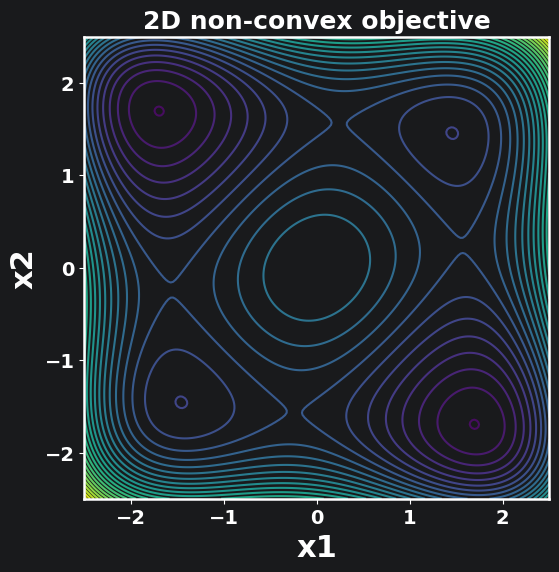

In [2]:
def multiwell2d():
    def fn(x):
        x1, x2 = x[0], x[1]
        L = 0.2 * (x1**4 + x2**4) - (x1**2 + x2**2) + 0.3 * x1 * x2
        g1 = 0.8 * x1**3 - 2 * x1 + 0.3 * x2
        g2 = 0.8 * x2**3 - 2 * x2 + 0.3 * x1
        g = torch.stack([g1, g2])
        return L, g
    return fn

def contour_plot_2d(loss_fn, xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), n=200):
    x1 = np.linspace(*xlim, n)
    x2 = np.linspace(*ylim, n)
    X1, X2 = np.meshgrid(x1, x2)
    Z = np.zeros_like(X1)

    for i in range(X1.shape[0]):
        pts = torch.tensor(np.stack([X1[i], X2[i]], axis=-1))
        vals = []
        for p in pts:
            L, _ = loss_fn(p)
            vals.append(float(L))
        Z[i] = np.array(vals)

    return X1, X2, Z

f2 = multiwell2d()
X1, X2, Z = contour_plot_2d(f2)

fig, ax = plt.subplots(figsize=(6,6))
ax.contour(X1, X2, Z, levels=30)
ax.set_title("2D non-convex objective", fontsize=18, fontweight="bold")
ax.set_xlabel("x1", fontsize=22, fontweight="bold")
ax.set_ylabel("x2", fontsize=22, fontweight="bold")
style_ax(ax)
plt.show()

## 2. Initialisation sensitivity near the centre

We now examine what happens when gradient descent is started from several points that are all **close to the central region** of the same 2D non-convex landscape.

The purpose of this experiment is to show that, even when the starting points are very close to one another, the optimisation trajectories can still diverge and end in **different basins of attraction**.

---

### What the code does

- We reuse the same 2D multiwell objective introduced above.
- Six initial points are chosen near the centre:

$$
(0.1,0.1),\;(-0.1,0.1),\;(0.1,-0.1),\;(-0.1,-0.1),\;(0,0.3),\;(0.3,0).
$$

- For each starting point, gradient descent is run for a fixed number of steps.
- The resulting trajectories are plotted on top of the contour map of the objective.

This makes it possible to compare how **small changes in the starting position** affect the subsequent descent.

---

### How to interpret the figure

Although all six initial points lie close to the centre, their trajectories do **not** remain similar.
Instead, they are pulled into different basins of the landscape.

This is a central feature of non-convex optimisation:

> Nearby starting points can lead to qualitatively different outcomes.

In particular, the plot highlights an important distinction between:

- the **theoretical global minimum**, which is the lowest point on the entire objective surface,
- and the **local minima** that gradient descent actually reaches from a given start.

Even though the global minimum exists somewhere on the landscape, the optimiser does not automatically find it. In fact, in this example, **most of the chosen starting points do not descend to the global minimum at all**. They instead settle into other locally attractive regions.

---

### Why this matters

This experiment shows why local gradient-based optimisation can be unreliable in non-convex problems:

- the update rule only uses **local slope information**
- it has no global understanding of which basin is best
- and the final solution can depend strongly on the starting point

So even when the global minimum is present in theory, it may play little role in practice if the optimiser never enters its basin of attraction.

This is one of the main reasons optimisation beyond convexity becomes difficult:

> **Finding a minimum is not the same as finding the globally best minimum.**

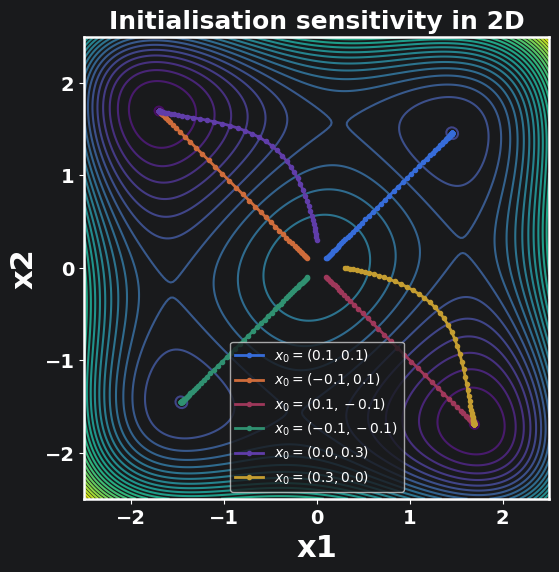

In [3]:
f2 = multiwell2d()
starts = [
    torch.tensor([ 0.1,  0.1]),
    torch.tensor([-0.1,  0.1]),
    torch.tensor([ 0.1, -0.1]),
    torch.tensor([-0.1, -0.1]),
    torch.tensor([ 0.0,  0.3]),
    torch.tensor([ 0.3,  0.0]),
]

lr = 0.05
steps = 80

X1, X2, Z = contour_plot_2d(f2)

fig, ax = plt.subplots(figsize=(6,6))
ax.contour(X1, X2, Z, levels=30)

for x0 in starts:
    xs, losses, _ = run_gd(x0, f2, lr=lr, steps=steps)
    path = xs.numpy()
    x0_fmt = tuple(np.round(x0.numpy(), 1).tolist())
    ax.plot(path[:,0], path[:,1], "-o", markersize=3, linewidth=2.0, label=rf"$x_0={x0_fmt}$")

ax.set_title("Initialisation sensitivity in 2D", fontsize=18, fontweight="bold")
ax.set_xlabel("x1", fontsize=22, fontweight="bold")
ax.set_ylabel("x2", fontsize=22, fontweight="bold")
ax.legend(prop={"size":10, "weight":"bold"})
style_ax(ax)
plt.show()

## 3. Noisy gradients on a simple convex landscape

So far, all of our optimisation experiments have been **deterministic**: once the starting point and learning rate are fixed, the trajectory is completely determined.

In many realistic settings, however, the gradient is not known exactly. Instead, the optimiser only sees an **approximate gradient**, which contains some amount of randomness or error. This leads to the idea of a **noisy gradient**.

A simple way to model this is

$$
\tilde{\nabla} L(x) = \nabla L(x) + \xi,
$$

where:
- $\nabla L(x)$ is the true gradient,
- $\xi$ is a random perturbation (noise).

This means that each update is no longer perfectly aligned with the true local descent direction.

---

### What the code does

We consider the quadratic objective

$$
L(x) = \frac{1}{2} x^\top A x,
\qquad
A =
\begin{pmatrix}
10 & 0 \\
0 & 1
\end{pmatrix},
$$

which defines a simple convex landscape with anisotropic curvature.

The code then:

- defines the quadratic objective and its exact gradient,
- computes the contour lines of the loss surface,
- runs **noisy gradient descent** from the same initial point
  $$
  x_0 = (2,2),
  $$
- and compares the trajectories for three different noise levels:
  $$
  \text{noise\_std} = 0.0,\; 0.2,\; 0.5.
  $$

---

### How to interpret the figure

The left panel corresponds to **noise-free** gradient descent, where the trajectory is smooth and fully determined by the objective.

As the noise level increases:

- the path becomes more **irregular**,
- the descent direction fluctuates from step to step,
- and the optimiser no longer follows the clean deterministic route.

Even though the underlying loss surface has not changed, the optimisation behaviour becomes increasingly stochastic.

---

### Why this matters

This is an important conceptual shift:

> Optimisation is no longer just about the geometry of the objective — it also depends on the quality of the gradient information.

Noise can therefore affect optimisation in two competing ways:

- it can **hurt** by making convergence slower, more erratic, or less stable,
- but it can also sometimes **help** by preventing the optimiser from getting trapped too easily in unfavourable regions.

In this cell, we focus on the first effect:
even on a simple convex landscape, noisy gradients already make the trajectory less smooth and less predictable.

This will prepare us for the next step, where we examine how noise affects optimisation **quantitatively**, not just geometrically.

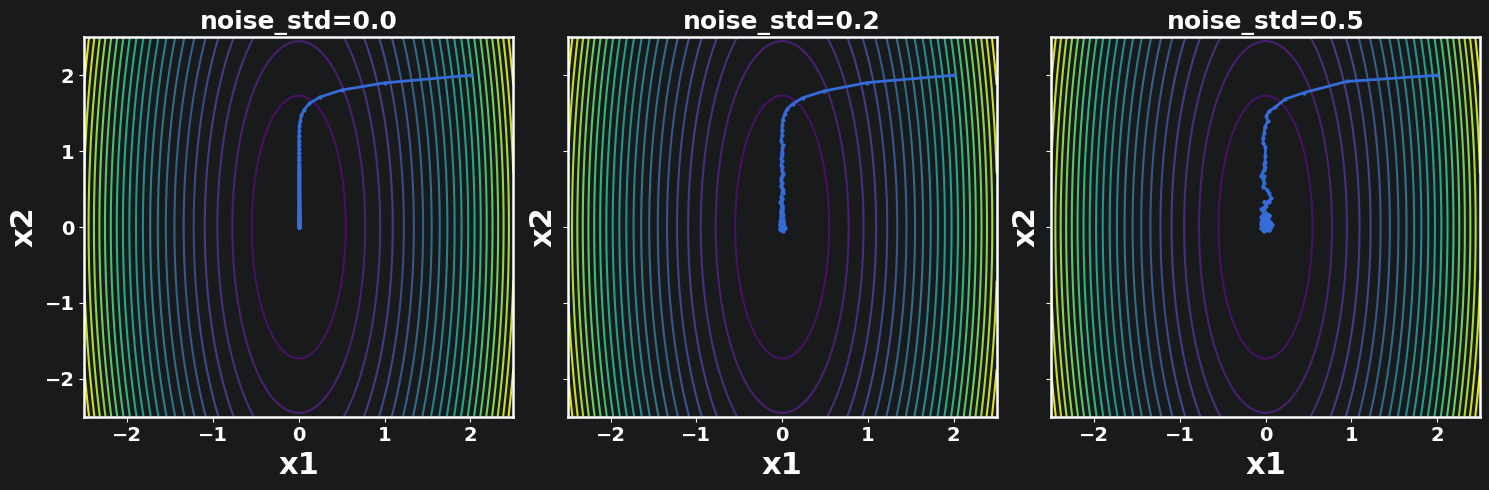

In [4]:
A = np.array([
    [10.0, 0.0],
    [0.0,  1.0]
])

def quad2d(A):
    A = torch.tensor(A)
    def fn(x):
        L = 0.5 * x @ (A @ x)
        g = A @ x
        return L, g
    return fn

fq = quad2d(A)
x0 = torch.tensor([2.0, 2.0])
lr = 0.05
steps = 120
noise_levels = [0.0, 0.2, 0.5]

def contour_plot_quad(A, xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), n=200):
    A = torch.tensor(A)
    x1 = np.linspace(*xlim, n)
    x2 = np.linspace(*ylim, n)
    X1, X2 = np.meshgrid(x1, x2)
    Z = np.zeros_like(X1)
    for i in range(X1.shape[0]):
        pts = torch.tensor(np.stack([X1[i], X2[i]], axis=-1))
        Z[i] = (0.5 * (pts * (pts @ A.T)).sum(dim=1)).numpy()
    return X1, X2, Z

X1, X2, Z = contour_plot_quad(A)

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharex=True, sharey=True)

for ax, noise_std in zip(axes, noise_levels):
    xs, losses, _ = run_noisy_gd(x0, fq, lr=lr, noise_std=noise_std, steps=steps)
    ax.contour(X1, X2, Z, levels=30)
    path = xs.numpy()
    ax.plot(path[:,0], path[:,1], "-o", markersize=2, linewidth=2.0)
    ax.set_title(f"noise_std={noise_std}", fontsize=18, fontweight="bold")
    ax.set_xlabel("x1", fontsize=22, fontweight="bold")
    ax.set_ylabel("x2", fontsize=22, fontweight="bold")
    style_ax(ax)

plt.tight_layout()
plt.show()

## 4. Noise affects convergence speed and variability

In the previous cell, we saw geometrically that adding noise makes individual optimisation trajectories less smooth.
We now examine the same effect **quantitatively** by looking at how the **loss evolves over time across many repeated runs**.

---

### What the code does

We use the same convex quadratic objective and the same starting point,

$$
x_0 = (2,2),
$$

but now run **multiple noisy gradient descent trajectories** for each noise level.

The experiment is repeated for

$$
\text{noise\_std} \in \{0.0,\;0.5,\;1.0\},
$$

with 20 independent trials for each value.

For every noise level, the code:

- runs 20 optimisation trajectories,
- records the loss at every step,
- plots each individual loss curve faintly,
- computes the **mean loss curve**,
- and shades the region corresponding to approximately one standard deviation around the mean.

The y-axis is shown on a **log scale**, so differences in convergence rate and variability are easier to see.

---

### How to interpret the figure

This figure shows two effects of noise very clearly.

#### 1. Noise slows convergence on average

The thick mean curves show that larger noise levels lead to **slower average decrease in loss**.

- The **noise-free** case decreases smoothly and steadily.
- The **moderately noisy** case still converges, but more slowly.
- The **high-noise** case converges much more slowly and begins to flatten at a higher loss level.

So even though all runs are optimising the same underlying objective, noisy gradients reduce the efficiency of descent.

---

#### 2. Noise makes optimisation outcomes more variable

The faint individual trajectories and shaded bands show that larger noise levels also produce much greater **run-to-run variability**.

- With no noise, every run is identical.
- With moderate noise, different runs begin to separate.
- With large noise, the spread becomes substantial: different runs can have noticeably different loss values at the same optimisation step.

This means that noisy gradients do not just make optimisation slower — they make it **less predictable**.

---

### Why this matters

This figure highlights an important distinction:

> Noise affects optimisation both in its **average behaviour** and in its **variability across runs**.

That is:

- it changes **how fast** optimisation progresses,
- and it changes **how reliable** that progress is.

This is one reason stochastic optimisation behaves differently from deterministic optimisation:
even on a simple convex problem, the gradient is no longer a perfectly trustworthy guide.

---

### Key takeaway

> As gradient noise increases, optimisation becomes both **slower** and **more variable**.

This is a fundamental shift from the deterministic picture developed earlier in Part 2.
The optimiser is now following not just the geometry of the loss surface, but also the randomness injected into the gradient itself.

In the next steps, we will connect this to a more subtle point: although noise can hurt convergence, it can also sometimes help an optimiser **escape locally unfavourable regions**.

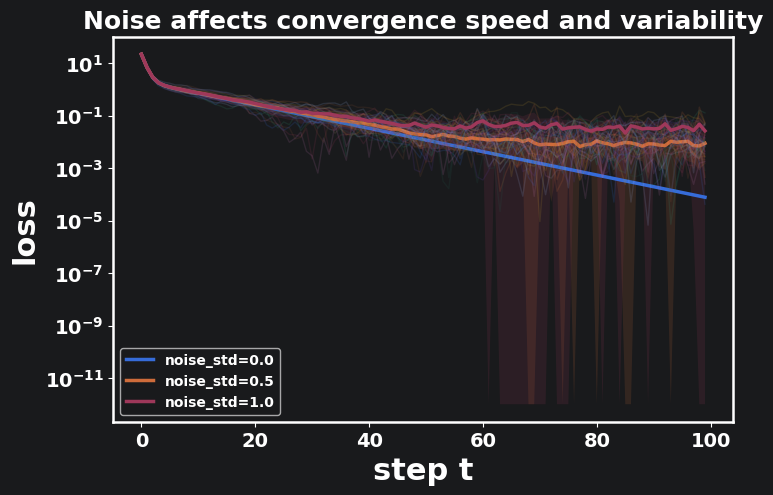

In [5]:
fq = quad2d(A)
x0 = torch.tensor([2.0, 2.0])
lr = 0.05
steps = 100
noise_levels = [0.0, 0.5, 1.0]
trials = 20

fig, ax = plt.subplots(figsize=(8,5))

for noise_std in noise_levels:
    all_losses = []

    for _ in range(trials):
        xs, losses, _ = run_noisy_gd(x0, fq, lr=lr, noise_std=noise_std, steps=steps)
        all_losses.append(losses)
        ax.plot(losses, linewidth=1.0, alpha=0.15)

    all_losses = np.array(all_losses)
    mean_losses = all_losses.mean(axis=0)
    std_losses = all_losses.std(axis=0)

    ax.plot(mean_losses, linewidth=2.5, label=f"noise_std={noise_std}")
    ax.fill_between(
        np.arange(steps),
        np.maximum(mean_losses - std_losses, 1e-12),
        mean_losses + std_losses,
        alpha=0.15
    )

ax.set_yscale("log")
ax.set_title("Noise affects convergence speed and variability", fontsize=18, fontweight="bold")
ax.set_xlabel("step t", fontsize=22, fontweight="bold")
ax.set_ylabel("loss", fontsize=22, fontweight="bold")
ax.legend(prop={"size":10, "weight":"bold"})
style_ax(ax)
plt.show()

## 5. Random restarts reveal multiple minima

We now make the initialisation dependence of local optimisation more explicit by using **many random restarts**.

Instead of choosing a few hand-picked starting points, we now sample a large number of random initial conditions and run the same gradient descent procedure from each one.

---

### What the code does

- `set_seed(0)` makes the experiment reproducible.
- `n_starts = 1000` random starting points are sampled in 2D.
- Each start is drawn from a Gaussian distribution and scaled outward:

$$
x_0 \sim 2 \cdot \mathcal{N}(0, I).
$$

- Gradient descent is run from each starting point using the same:
  - learning rate,
  - number of steps,
  - and objective function.

For each run, we record the **final loss value** after optimisation.

---

### What do different loss levels mean?

This is the key idea of the cell.

If every run of gradient descent ended in the **same minimum**, then all final losses would be essentially identical.
But here, the final losses cluster into **different repeated values**.

That means:

> **different runs are converging to different minima of the same objective.**

In other words, each distinct final loss level corresponds to a different basin of attraction in the non-convex landscape.

For example, if the printed output shows something like

- loss = $-3.3060$
- loss = $-1.8060$

then these are not just arbitrary numbers — they indicate that gradient descent has found **two different types of final solution**.

Typically:

- the **lower** final loss corresponds to a **better minimum**
- the **higher** final loss corresponds to a **worse local minimum**

So the bar plot is effectively counting:

> how often random initialisation causes the optimiser to land in each minimum.

---

### How to interpret the figure

Each bar shows the number of optimisation runs that ended at a particular final loss level.

This gives a compact summary of the basin structure of the landscape:

- a **taller bar** means that minimum attracts more random starts,
- a **shorter bar** means that minimum is reached less often.

So the figure tells us not just that multiple minima exist, but also something about their **relative basin sizes**.

---

### Why this matters

This experiment highlights one of the main limitations of local gradient-based optimisation in non-convex problems:

> Even when the optimisation algorithm is deterministic, the final answer can still depend strongly on where it starts.

Random restarts can improve the chance of finding a good solution, but they do not remove the core difficulty:
- the optimiser still only uses **local information**
- and different starting points can still lead to different final answers

---

### Key takeaway

> Different final loss levels mean that the optimiser has converged to different minima.

This is a practical signature of non-convexity:
- the objective has multiple attractive solutions,
- not all of them are equally good,
- and random initialisation can strongly affect which one is found.

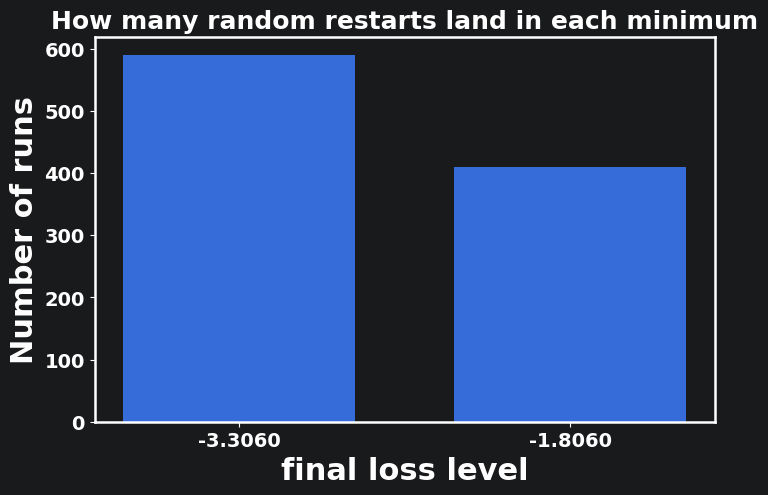

Unique final losses:
loss = -3.3060  ->  590 runs
loss = -1.8060  ->  410 runs


In [6]:
set_seed(0)

f2 = multiwell2d()
lr = 0.05
steps = 100
n_starts = 1000

starts = [2.0 * torch.randn(2) for _ in range(n_starts)]
endpoints = []
losses_final = []

for x0 in starts:
    xs, losses, _ = run_gd(x0, f2, lr=lr, steps=steps)
    endpoints.append(xs[-1].numpy())
    losses_final.append(losses[-1])

endpoints = np.array(endpoints)

# Count how many runs land in each distinct final-loss level
rounded_losses = np.round(np.array(losses_final), 3)
unique_losses, counts = np.unique(rounded_losses, return_counts=True)

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(np.arange(len(unique_losses)), counts, width=0.7)

ax.set_xticks(np.arange(len(unique_losses)))
ax.set_xticklabels([f"{loss:.4f}" for loss in unique_losses])

ax.set_title("How many random restarts land in each minimum", fontsize=18, fontweight="bold")
ax.set_xlabel("final loss level", fontsize=22, fontweight="bold")
ax.set_ylabel("Number of runs", fontsize=22, fontweight="bold")

style_ax(ax)
plt.show()

print("Unique final losses:")
for loss, count in zip(unique_losses, counts):
    print(f"loss = {loss:.4f}  ->  {count} runs")

## 6. Noise can help escape a worse basin

So far, we have seen that noise can make optimisation trajectories less smooth and less predictable.
However, noise does not always act purely as a nuisance.

In a non-convex landscape, if the starting point lies near a **basin boundary**, a small amount of noise can sometimes push the optimiser away from the basin it would have followed deterministically and into a different, potentially better one.

This cell illustrates that effect directly.

---

### What the code does

We again use the 2D multiwell objective, but now choose a starting point close to the central region:

$$
x_0 = (0.05, 0.05).
$$

This point lies near a region where the local descent direction is sensitive to perturbation.

The experiment is run for several noise levels:

$$
\text{noise\_std} \in \{0.00,\;0.05,\;0.10,\;0.20,\;0.40\}.
$$

For each noise level:

- 100 noisy gradient descent runs are performed from the same starting point,
- the final endpoint of each run is recorded,
- and the final loss is used to classify the outcome.

Based on the earlier random-restart experiment, we identify two main types of minima:

- **better minimum** with lower final loss (around $-3.306$),
- **worse minimum** with higher final loss (around $-1.806$).

Any runs that do not fall clearly into either category are labelled as **other**.

---

### Part 1: endpoint clouds on the contour map

The first figure shows where the optimisation runs end up for each noise level.

Each panel corresponds to one value of `noise_std`, and the points are coloured according to which basin they reach:

- **blue**: worse basin
- **orange**: better basin
- **gray**: other / not clearly converged
- **green square**: the common starting point

This lets us see how increasing noise changes the **spatial distribution of outcomes**.

---

### What the first figure shows

At very low noise, the runs tend to end in the same basin repeatedly.
As the noise level increases, the endpoints begin to spread out more, and some runs cross into a different basin.

This shows that:

> **Noise can change not just the optimisation path, but the final minimum that is reached.**

In particular, if the deterministic trajectory would have fallen into a worse local basin, moderate noise can sometimes help the optimiser escape that fate and land in a better one.

---

### Part 2: probability of reaching each basin

The second figure summarises the same phenomenon more clearly.

For each noise level, we compute the proportion of runs that end in:

- the **worse basin**
- the **better basin**
- or **other / not clearly converged**

The stacked bar chart therefore turns the endpoint clouds into a direct probability statement.

---

### How to interpret the second figure

The key question is:

> As noise increases, how does the chance of reaching the better minimum change?

If the proportion of runs reaching the better basin rises with noise, that means noise is helping some trajectories cross the basin boundary and avoid the worse deterministic outcome.

This is a subtle but important point:

- noise can **hurt local convergence**
- but it can also **help basin switching**

So its role in non-convex optimisation is not purely negative.

---

### Why this matters

This cell reveals a deeper lesson than “noise makes optimisation messy.”

In non-convex landscapes, noise can play two opposing roles:

- **harmful**: by slowing convergence and increasing variability
- **helpful**: by allowing trajectories to escape a basin they would otherwise remain trapped in

This is exactly why stochastic optimisation is more subtle than deterministic optimisation.

The effect of noise depends not only on its magnitude, but also on **where the optimiser starts in the landscape**.

---

### Key takeaway

> Near a basin boundary, noise can increase the chance of reaching a better minimum.

So while noise reduces smoothness and predictability, it can also introduce a useful form of **exploration**.

This trade-off between:
- clean local convergence,
- and the ability to escape unfavourable regions,

is one of the central ideas behind optimisation beyond convexity.

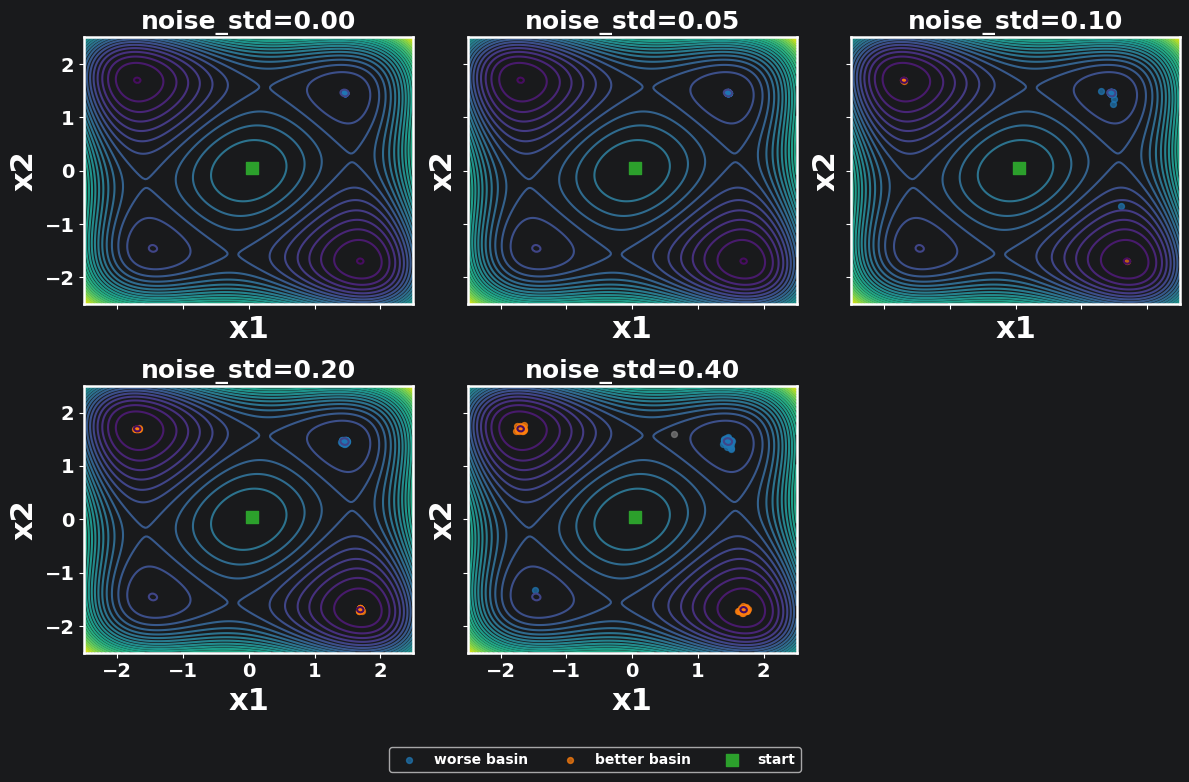

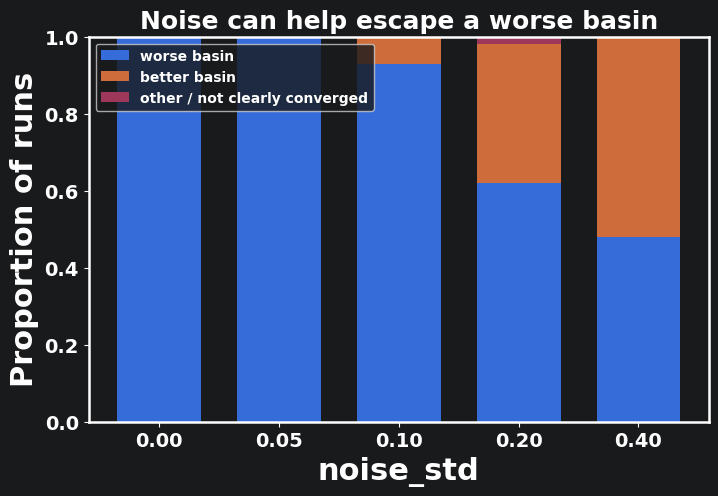

In [7]:
set_seed(0)

f2 = multiwell2d()
x0 = torch.tensor([0.05, 0.05])
lr = 0.05
steps = 100
trials = 100
noise_levels_escape = [0.0, 0.05, 0.1, 0.2, 0.4]

# From the random-restart experiment:
best_loss = -3.306
worse_loss = -1.806

X1, X2, Z = contour_plot_2d(f2)

fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, noise_std in zip(axes, noise_levels_escape):
    endpoints = []
    final_losses = []

    for _ in range(trials):
        xs, losses, _ = run_noisy_gd(x0, f2, lr=lr, noise_std=noise_std, steps=steps)
        endpoints.append(xs[-1].numpy())
        final_losses.append(losses[-1])

    endpoints = np.array(endpoints)
    final_losses = np.array(final_losses)

    close_to_best = np.abs(final_losses - best_loss) < 0.1
    close_to_worse = np.abs(final_losses - worse_loss) < 0.1
    other_mask = ~(close_to_best | close_to_worse)

    ax.contour(X1, X2, Z, levels=30)

    ax.scatter(
        endpoints[close_to_worse, 0], endpoints[close_to_worse, 1],
        s=18, alpha=0.7, color="tab:blue", label="worse basin"
    )
    ax.scatter(
        endpoints[close_to_best, 0], endpoints[close_to_best, 1],
        s=18, alpha=0.7, color="tab:orange", label="better basin"
    )
    if np.any(other_mask):
        ax.scatter(
            endpoints[other_mask, 0], endpoints[other_mask, 1],
            s=18, alpha=0.7, color="tab:gray", label="other"
        )

    ax.scatter(
        x0[0].item(), x0[1].item(),
        s=70, marker="s", color="tab:green", label="start"
    )
    ax.set_title(f"noise_std={noise_std:.2f}", fontsize=18, fontweight="bold")
    ax.set_xlabel("x1", fontsize=22, fontweight="bold")
    ax.set_ylabel("x2", fontsize=22, fontweight="bold")
    style_ax(ax)

for ax in axes[len(noise_levels_escape):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    prop={"size":10, "weight":"bold"}
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


better_probs = []
worse_probs = []
other_probs = []

for noise_std in noise_levels_escape:
    final_losses = []

    for _ in range(trials):
        xs, losses, _ = run_noisy_gd(x0, f2, lr=lr, noise_std=noise_std, steps=steps)
        final_losses.append(losses[-1])

    final_losses = np.array(final_losses)

    close_to_best = np.abs(final_losses - best_loss) < 0.1
    close_to_worse = np.abs(final_losses - worse_loss) < 0.1
    other_mask = ~(close_to_best | close_to_worse)

    better_probs.append(np.mean(close_to_best))
    worse_probs.append(np.mean(close_to_worse))
    other_probs.append(np.mean(other_mask))

fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(len(noise_levels_escape))

for vals, label in zip(
    [worse_probs, better_probs, other_probs],
    ["worse basin", "better basin", "other / not clearly converged"]
):
    vals = np.array(vals)
    ax.bar(np.arange(len(noise_levels_escape)), vals, bottom=bottom, width=0.7, label=label)
    bottom += vals

ax.set_xticks(np.arange(len(noise_levels_escape)))
ax.set_xticklabels([f"{n:.2f}" for n in noise_levels_escape])
ax.set_ylim(0, 1)
ax.set_title("Noise can help escape a worse basin", fontsize=18, fontweight="bold")
ax.set_xlabel("noise_std", fontsize=22, fontweight="bold")
ax.set_ylabel("Proportion of runs", fontsize=22, fontweight="bold")
ax.legend(prop={"size":10, "weight":"bold"}, loc="upper left")
style_ax(ax)
plt.show()

## 7. Noise hurts local convergence when basin escape is unnecessary

In the previous experiments, we saw that noise can sometimes help optimisation by pushing trajectories across basin boundaries.
However, that is only one side of the story.

To isolate the opposite effect, we now choose a starting point that is already **well inside a good basin**. In this regime, the optimiser does not need help escaping; it simply needs to converge efficiently to the nearby minimum.

This allows us to study a cleaner question:

> What does noise do when the local descent direction is already pointing toward the right solution?

---

### What the code does

- We reuse the same 2D non-convex objective `multiwell2d()`.
- The initial point is chosen as

$$
x_0 = (1.8,\,-1.7),
$$

which lies clearly inside the lower-right basin.

- For each noise level

$$
\text{noise\_std} \in \{0.00,\;0.05,\;0.10,\;0.20,\;0.40,\;0.60\},
$$

we run 100 independent noisy optimisation trajectories.

- For each run, we record the **final loss after 60 steps**.

The results are then summarised in two ways:

1. a **box plot**, showing the distribution of final losses across runs,
2. a **mean ± standard deviation plot**, showing how the average final loss changes with noise level.

---

### Why this setup is important

This experiment is deliberately different from the basin-switching case.

Here:
- the starting point is already inside a desirable basin,
- there is no major topological barrier to cross,
- and the main task of optimisation is simply to settle into the local minimum as efficiently as possible.

So if noise now worsens performance, that cannot be explained by a failure to escape a bad basin.
It is a more direct demonstration that:

> **noise can degrade local convergence even when the optimiser is already in the right place.**

### Part 1: distribution of final losses across runs

The first figure summarises the outcome of many noisy optimisation runs using a **box plot**.

For each value of `noise_std`, we run gradient descent 100 times from the same starting point and record the **final loss after 60 steps**.

Each box therefore shows:

- the typical final loss,
- the spread across runs,
- and how stable the optimisation is under that noise level.

Because the starting point is already well inside one basin, these differences are not about basin switching. They reflect how much noise disrupts **local convergence within the same basin**.

---

### What the first figure shows

As the noise level increases:

- the distribution of final losses shifts upward,
- the spread becomes wider,
- and the optimisation outcomes become less consistent across repeated runs.

This means that stronger noise makes convergence:

- **less accurate**, because the final loss is higher on average,
- and **less reliable**, because different runs end at more variable loss values.

So in this regime, noise is no longer helping exploration. It is simply making local descent less efficient.

---

### Part 2: mean final loss as a function of noise level

The second figure compresses the same information into a simpler summary.

For each noise level, we compute:

- the **mean final loss** across 100 runs,
- and the **standard deviation** of that final loss.

The line shows the average optimisation performance, while the shaded region shows how much variability remains across runs.

---

### What the second figure shows

The main trend is clear:

> As noise increases, the average final loss worsens.

This gives a clean practical interpretation of the same experiment:

- if the optimiser is already inside a good basin,
- and the goal is simply to converge efficiently,
- then adding more noise tends to **hurt** rather than help.

The widening shaded band also shows that stronger noise makes the final performance increasingly uncertain.

---

### Key takeaway

This pair of figures complements the earlier basin-switching experiment.

- **Near a basin boundary**, noise can help by pushing trajectories into a better basin.
- **Inside a basin**, noise usually hurts by preventing clean local convergence.

So the effect of noise depends strongly on **where the optimiser starts** and **what role the noise is playing**.

This is one of the central lessons of optimisation beyond convexity:

> The same randomness can either help exploration or damage convergence, depending on the geometry of the landscape.

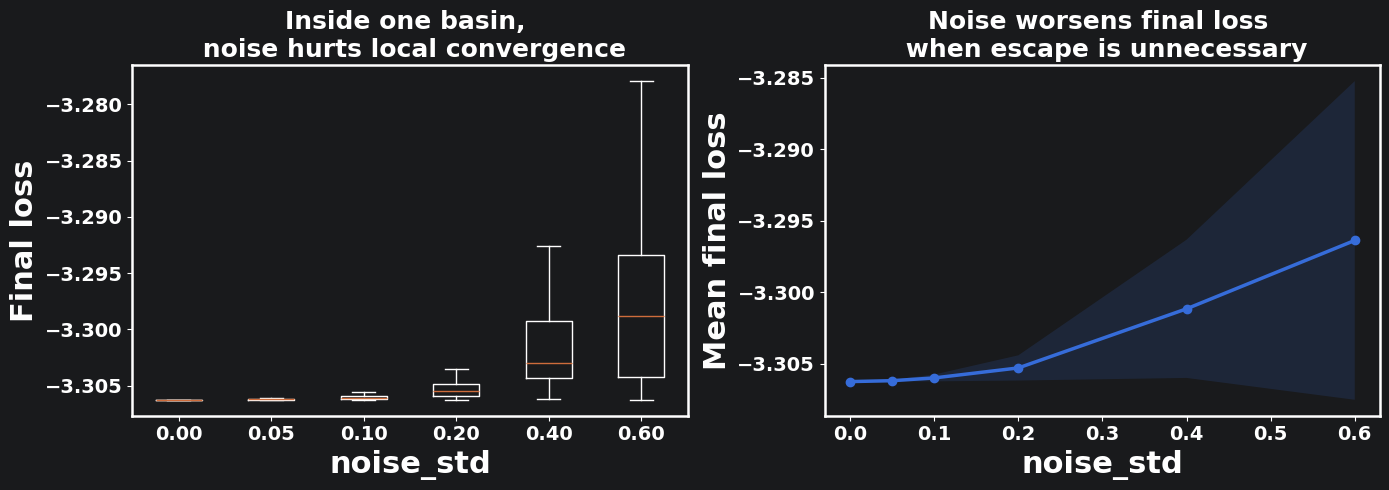

In [8]:
set_seed(0)

f2 = multiwell2d()
x0 = torch.tensor([1.8, -1.7])
lr = 0.05
steps = 60
noise_levels_inside = [0.0, 0.05, 0.1, 0.2, 0.4, 0.6]
trials = 100

final_losses_inside = []

for noise_std in noise_levels_inside:
    finals = []
    for _ in range(trials):
        xs, losses, _ = run_noisy_gd(x0, f2, lr=lr, noise_std=noise_std, steps=steps)
        finals.append(losses[-1])
    final_losses_inside.append(np.array(finals))

mean_final_losses_inside = np.array([arr.mean() for arr in final_losses_inside])
std_final_losses_inside = np.array([arr.std() for arr in final_losses_inside])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(
    final_losses_inside,
    tick_labels=[f"{n:.2f}" for n in noise_levels_inside],
    showfliers=False
)
axes[0].set_title("Inside one basin, \n noise hurts local convergence", fontsize=18, fontweight="bold")
axes[0].set_xlabel("noise_std", fontsize=22, fontweight="bold")
axes[0].set_ylabel("Final loss", fontsize=22, fontweight="bold")
style_ax(axes[0])

axes[1].plot(noise_levels_inside, mean_final_losses_inside, "-o", linewidth=2.5)
axes[1].fill_between(
    noise_levels_inside,
    mean_final_losses_inside - std_final_losses_inside,
    mean_final_losses_inside + std_final_losses_inside,
    alpha=0.15
)
axes[1].set_title("Noise worsens final loss \n when escape is unnecessary", fontsize=18, fontweight="bold")
axes[1].set_xlabel("noise_std", fontsize=22, fontweight="bold")
axes[1].set_ylabel("Mean final loss", fontsize=22, fontweight="bold")
style_ax(axes[1])

plt.tight_layout()
plt.show()

## 8. Noise slows the decay of gradient norms

In the previous cells, we examined how noise affects optimisation in terms of **trajectories**, **final basin selection**, and **final loss**.
We now look at the same phenomenon from a slightly different angle: the **size of the gradient itself** during optimisation.

---

### What does `grad_norm` mean here?

At each optimisation step, the code computes the gradient

$$
g_t = \nabla L(x_t),
$$

and then records its Euclidean norm

$$
\|g_t\| = \sqrt{g_{t,1}^2 + g_{t,2}^2}.
$$

This quantity is called the **gradient norm**.

It tells us how large the gradient is at the current point:
- a **large** gradient norm means the optimiser is still in a region with strong descent signal,
- a **small** gradient norm means the optimiser is approaching a stationary region, such as a minimum.

So the gradient norm is a useful way to track **how close optimisation is to settling down**.

---

### What the code does

We use the same convex quadratic objective as before,

$$
L(x) = \frac{1}{2} x^\top A x,
\qquad
A =
\begin{pmatrix}
10 & 0 \\
0 & 1
\end{pmatrix},
$$

starting from

$$
x_0 = (2,2).
$$

For each noise level

$$
\text{noise\_std} \in \{0.0,\;0.2,\;0.5,\;1.0\},
$$

we run 20 independent noisy gradient descent trajectories.

At every step, we record the gradient norm, then compute:
- the **mean gradient norm** across runs,
- and the **standard deviation** across runs.

The plot shows the mean as a line and the variability as a shaded band.

The y-axis is drawn on a **log scale** so that differences in decay behaviour are easier to see.

---

### How to interpret the figure

The figure shows a clear pattern:

- in the **noise-free** case, the gradient norm decays steadily toward zero,
- with **moderate noise**, the decay becomes slower,
- with **larger noise**, the gradient norm stops shrinking cleanly and instead levels off at a higher value.

This means that as the noise increases, the optimiser has more difficulty settling into a region where the gradient is genuinely small.

The shaded bands also become wider at higher noise levels, showing that the gradient norm becomes more variable from run to run.

---

### Why this matters

This gives a more mechanistic view of why noise hurts local convergence.

When optimisation is working cleanly, we expect

$$
\|\nabla L(x_t)\| \to 0,
$$

because the trajectory is approaching a minimum.

But with noisy updates, the optimiser keeps getting kicked away from the smooth descent direction, so the gradient norm no longer decays as effectively.

In that sense, noise does not only slow the decrease of the loss — it also prevents the optimiser from fully **stabilising near a stationary point**.

---

### Key takeaway

> Larger noise keeps the optimiser in regions with larger gradients for longer.

So the gradient norm plot complements the earlier loss plots:

- the **loss** tells us how well optimisation is performing,
- the **gradient norm** tells us how cleanly the optimiser is settling down.

Together, they show that stronger noise makes optimisation:
- slower,
- more variable,
- and less able to converge smoothly to a stationary solution.

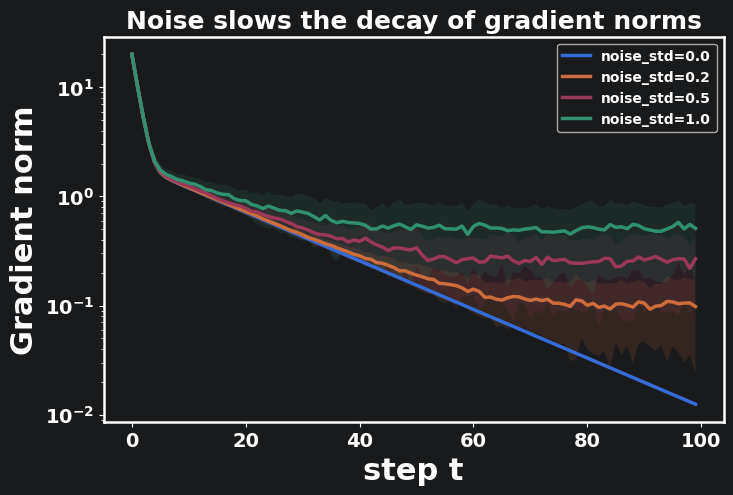

In [9]:
set_seed(0)

fq = quad2d(A)
x0 = torch.tensor([2.0, 2.0])
lr = 0.05
steps = 100
noise_levels = [0.0, 0.2, 0.5, 1.0]
trials = 100

fig, ax = plt.subplots(figsize=(8, 5))

for noise_std in noise_levels:
    all_grad_norms = []

    for _ in range(trials):
        xs, losses, grad_norms = run_noisy_gd(x0, fq, lr=lr, noise_std=noise_std, steps=steps)
        all_grad_norms.append(grad_norms)

    all_grad_norms = np.array(all_grad_norms)
    mean_grad_norms = all_grad_norms.mean(axis=0)
    std_grad_norms = all_grad_norms.std(axis=0)

    ax.plot(mean_grad_norms, linewidth=2.5, label=f"noise_std={noise_std}")
    ax.fill_between(
        np.arange(steps),
        np.maximum(mean_grad_norms - std_grad_norms, 1e-12),
        mean_grad_norms + std_grad_norms,
        alpha=0.15
    )

ax.set_yscale("log")
ax.set_title("Noise slows the decay of gradient norms", fontsize=18, fontweight="bold")
ax.set_xlabel("step t", fontsize=22, fontweight="bold")
ax.set_ylabel("Gradient norm", fontsize=22, fontweight="bold")
ax.legend(prop={"size":10, "weight":"bold"})
style_ax(ax)
plt.show()

## 9. Final loss after a fixed compute budget



So far, we have studied noise in two different ways:

- how it changes **which basin** the optimiser reaches,
- and how it affects **local convergence** once the optimiser is inside a basin.

We now combine these ideas into a more practical question:

> If we allow the same fixed number of optimisation steps, how does the final performance depend on the noise level?

This is a useful viewpoint because, in practice, optimisation is often run under a **finite compute budget** rather than until perfect convergence.

---

### What the code does

We again use the same 2D non-convex objective and the same starting point near the central region,

$$
x_0 = (0.05, 0.05),
$$

but now fix the optimisation budget to

$$
60 \text{ steps}.
$$

For each noise level

$$
\text{noise\_std} \in \{0.00,\;0.05,\;0.10,\;0.20,\;0.40,\;0.60\},
$$

we run 100 noisy optimisation trajectories and record the **final loss after 60 steps**.

The results are then shown as a box plot, which summarises the distribution of final losses across repeated runs.

---

### How to interpret the figure

Each box corresponds to one noise level and shows the range of final losses obtained after the same compute budget.

Several features are worth noticing:

- For **small noise**, the final losses are tightly concentrated, meaning the optimisation outcome is highly consistent.
- As the noise level increases, the spread becomes much wider.
- At intermediate and larger noise levels, the distribution often becomes **bimodal in spirit**, with some runs ending near a worse local minimum and others reaching a better one.

This reflects the two competing roles of noise:

- it can **hurt** convergence by making the descent less stable,
- but it can also **help** by allowing some trajectories to escape a worse basin and reach a better one.

---

### What the figure shows

The box plot makes one important fact very clear:

> **The effect of noise is not simply monotonic in a non-convex problem.**

At low noise, optimisation is more predictable but may remain trapped in an unfavourable basin.

At higher noise, the outcomes become much more variable:
- some runs improve substantially by escaping,
- while others remain worse or become unstable.

So noise creates a trade-off between:

- **consistency**,
- **local convergence quality**,
- and **the chance of discovering a better minimum**.

---

### Why this matters

This is a more realistic way to think about optimisation in practice.

When the compute budget is fixed, we do not only care about:
- asymptotic convergence,
- or average behaviour in the limit of many steps.

We also care about:

> **what quality of solution we obtain within the time we are actually willing to spend.**

This figure shows that, in non-convex optimisation, the answer can depend strongly on the noise level.

---

### Key takeaway

> Under a fixed compute budget, noise changes not only the average final loss, but also the entire distribution of possible outcomes.

This is why noisy optimisation is more subtle than deterministic optimisation:
- low noise gives stable but potentially trapped behaviour,
- higher noise increases variability,
- and some amount of noise may improve the chance of finding a better solution, even if it also makes outcomes less predictable.

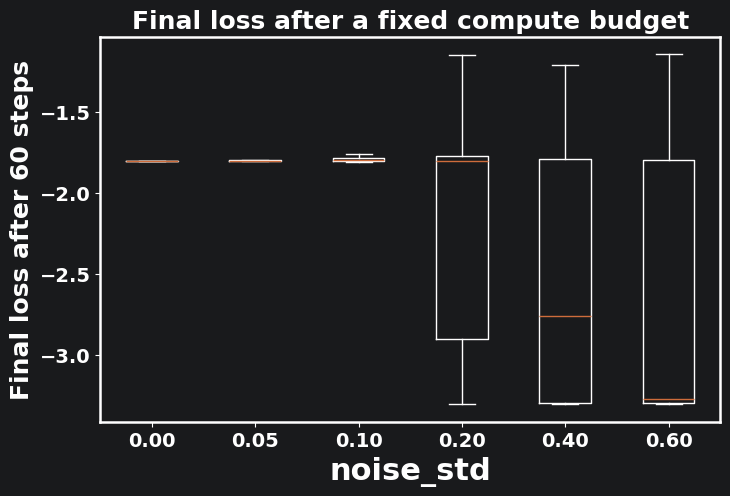

In [10]:
set_seed(0)

f2 = multiwell2d()
x0 = torch.tensor([0.05, 0.05])
lr = 0.05
steps = 60
noise_levels_budget = [0.0, 0.05, 0.1, 0.2, 0.4, 0.6]
trials = 100

final_losses_by_noise = []

for noise_std in noise_levels_budget:
    finals = []
    for _ in range(trials):
        xs, losses, _ = run_noisy_gd(x0, f2, lr=lr, noise_std=noise_std, steps=steps)
        finals.append(losses[-1])
    final_losses_by_noise.append(np.array(finals))

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(final_losses_by_noise, tick_labels=[f"{n:.2f}" for n in noise_levels_budget], showfliers=False)
ax.set_title("Final loss after a fixed compute budget", fontsize=18, fontweight="bold")
ax.set_xlabel("noise_std", fontsize=22, fontweight="bold")
ax.set_ylabel("Final loss after 60 steps", fontsize=18, fontweight="bold")
style_ax(ax)
plt.show()

## 10. Final-loss vs noise trade-off

The previous box plot showed the full distribution of final losses after a fixed compute budget.
We now summarise the same experiment more compactly by plotting:

- the **mean final loss** across runs,
- together with a shaded band representing one standard deviation.

This gives a clearer high-level picture of how optimisation performance changes as the noise level increases.

---

### What the code does

For each value of `noise_std`, we take the collection of final losses stored in `final_losses_by_noise` and compute:

- the **mean**
- and the **standard deviation**

across all trials.

These are then plotted against the noise level.

The line shows the average final outcome after 60 optimisation steps, while the shaded region shows how much variability remains across repeated runs.

---

### How to interpret the figure

This figure highlights an important trade-off.

As the noise level increases:

- the **mean final loss becomes lower**,
- but the **uncertainty around that mean becomes much larger**.

So in this experiment, larger noise improves the average outcome, but only by making the optimisation much less predictable.

This happens because noise has two competing effects:

- it can **help** some trajectories escape a worse basin and reach a better minimum,
- but it also makes the optimisation dynamics more variable and less stable.

---

### Why this matters

This is a more realistic way to think about optimisation in non-convex settings.

In practice, we often care not only about whether an optimiser can converge in theory, but about:

> **what quality of solution we obtain within a limited compute budget.**

This figure shows that the answer may depend strongly on the amount of noise present.

A small amount of noise may leave the optimiser trapped in a worse basin, while a larger amount of noise may improve the average outcome by increasing the chance of basin escape.

However, that improvement comes with a cost:
- the results become much more spread out from run to run,
- and the optimisation becomes less reliable.

---

### Key takeaway

> Under a fixed compute budget, noise can improve the **average** final solution while simultaneously making optimisation more **variable**.

So the role of noise is genuinely two-sided:

- it may help **exploration**,
- but it may hurt **stability and consistency**.

This is why optimisation beyond convexity cannot be understood only in terms of deterministic descent.
The final outcome depends not just on the landscape, but also on how randomness interacts with that landscape over time.

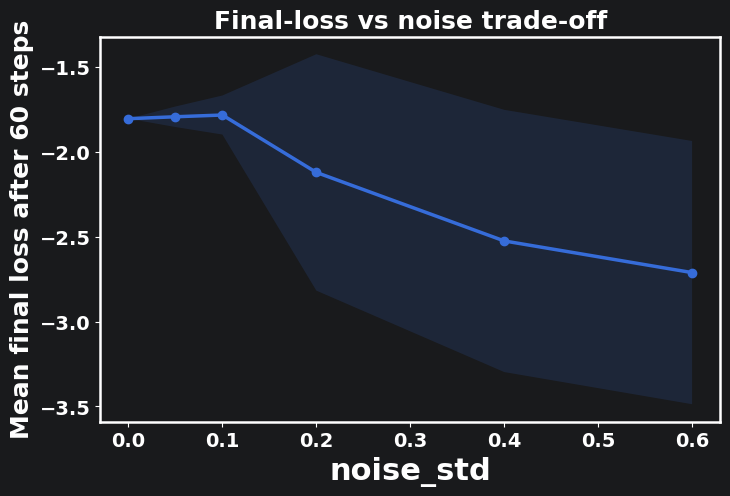

In [11]:
mean_final_losses = np.array([arr.mean() for arr in final_losses_by_noise])
std_final_losses = np.array([arr.std() for arr in final_losses_by_noise])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(noise_levels_budget, mean_final_losses, "-o", linewidth=2.5)
ax.fill_between(
    noise_levels_budget,
    mean_final_losses - std_final_losses,
    mean_final_losses + std_final_losses,
    alpha=0.15
)

ax.set_title("Final-loss vs noise trade-off", fontsize=18, fontweight="bold")
ax.set_xlabel("noise_std", fontsize=22, fontweight="bold")
ax.set_ylabel("Mean final loss after 60 steps", fontsize=18, fontweight="bold")
style_ax(ax)
plt.show()

## 🧭 Closing Remarks

In this tutorial, we moved from optimisation in well-behaved settings to a regime where the **structure of the landscape itself fundamentally limits what gradient descent can achieve**.

That was the central shift of the notebook.

Up to this point in Part 2, we studied how optimisation behaves given:
- a known objective,
- a fixed update rule,
- and reasonably structured geometry.

Here, we removed that safety.

By introducing a simple but expressive **2D non-convex objective**, we saw that many familiar assumptions no longer hold.

---

The first key idea was **basin dependence**.

Through initialisation experiments and random restarts, we observed that:
- the same optimisation algorithm,
- applied to the same objective,
- can converge to **different final solutions**.

These outcomes are not small variations of one another — they correspond to **distinct minima** with different objective values.

This leads to a fundamental shift in thinking:

> optimisation is no longer only about *how fast* we converge, but also about *where* we converge.

---

The second key idea was the role of **noise**.

By introducing noisy gradients, we made optimisation explicitly stochastic.
This revealed two competing effects:

- **local degradation**:
  - slower convergence,
  - noisier trajectories,
  - and larger residual gradients near minima.

- **global exploration**:
  - the ability to cross basin boundaries,
  - and the chance of reaching better minima that deterministic descent would miss.

This dual role of noise is one of the most important conceptual outcomes of the tutorial:

> noise does not have a single effect — it interacts with the geometry of the landscape in a context-dependent way.

---

This led to a clearer structural understanding of optimisation behaviour.

We saw that:

- **near basin boundaries**, noise can be beneficial because it enables transitions between regions of the landscape,
- **deep inside a basin**, noise is harmful because it disrupts clean convergence,
- and under a **fixed compute budget**, these effects combine into a genuine trade-off between:
  - average performance,
  - variability,
  - and reliability.

This is why the final-loss experiments were especially important.

They showed that:

> optimisation outcomes in non-convex problems are not single numbers, but **distributions** shaped by both geometry and randomness.

---

Taken together, the experiments in this tutorial unify several phenomena:

- initialisation sensitivity,
- multiple minima,
- stochastic trajectories,
- basin switching,
- and variability under repeated runs.

These are not separate issues.
They are different expressions of the same underlying fact:

> once the landscape is non-convex, optimisation becomes a **global search problem under local information constraints**.

---

This gives the tutorial a clear role in Part 2.

- Tutorial 1: gradient descent as a dynamical system
- Tutorial 2: geometry and conditioning
- Tutorial 3: modifying dynamics (momentum)
- **Tutorial 4: limits of local optimisation in non-convex landscapes**

This is the point where the perspective of Part 2 reaches its natural boundary.

So far, we have assumed:
- the objective is known,
- gradients are available (possibly noisy),
- and optimisation proceeds by local updates.

But this tutorial shows that these assumptions are no longer sufficient for reliable global performance.

---

So the main takeaway is:

> in non-convex optimisation, good local updates do not guarantee good global outcomes.

This is exactly why the next step is necessary.

In **Part 3**, we move beyond optimisation alone and begin to introduce **modelling and uncertainty**.

Instead of asking only:
- *how should we update parameters given a gradient?*

we will ask:
- *how should we choose where to evaluate the function next, when the function itself is unknown?*

That shift leads naturally to:
- surrogate models,
- uncertainty quantification,
- and Bayesian optimisation.

So the deeper conclusion of this tutorial is:

> when the landscape is complex and information is limited, optimisation must be guided not only by gradients, but by **what we choose to learn about the objective itself**.